### 1. Environment Config

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os

# Global Environment Configurations
DATA_PATH = "mnist.csv"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

if not os.path.exists("plots"):
    os.makedirs("plots")

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


### 2.Loading and Processing Data

In [6]:
def load_data_global(path, sample_size=None):
    """
    Load data and apply pre-processing
    """
    print(f"Loading data from {path}...")
    if not os.path.exists(path):
        print("Error: File not found. Please check DATA_PATH.")
        return None, None

    df = pd.read_csv(path)

    # Sample Size Adjustments
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)
        print(f"Data sampled to {sample_size} rows.")

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    print(f"Data Loaded Successfully. Shape: {X.shape}")
    return X, y

# Data Loading
X_global, y_global = load_data_global(DATA_PATH, sample_size=10000)

Loading data from mnist.csv...
Data Loaded Successfully. Shape: (5000, 784)


### 3. Define Visualizations


--- Running Visual Structure Analysis (Heat Plot) ---


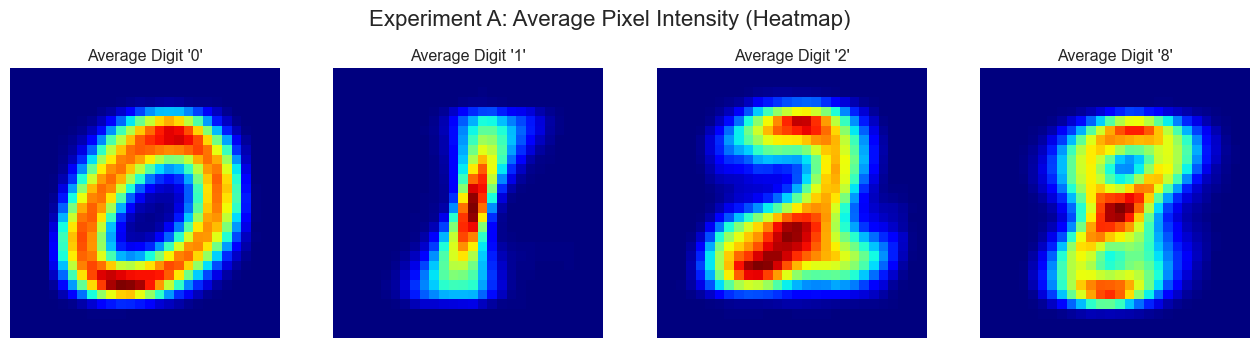

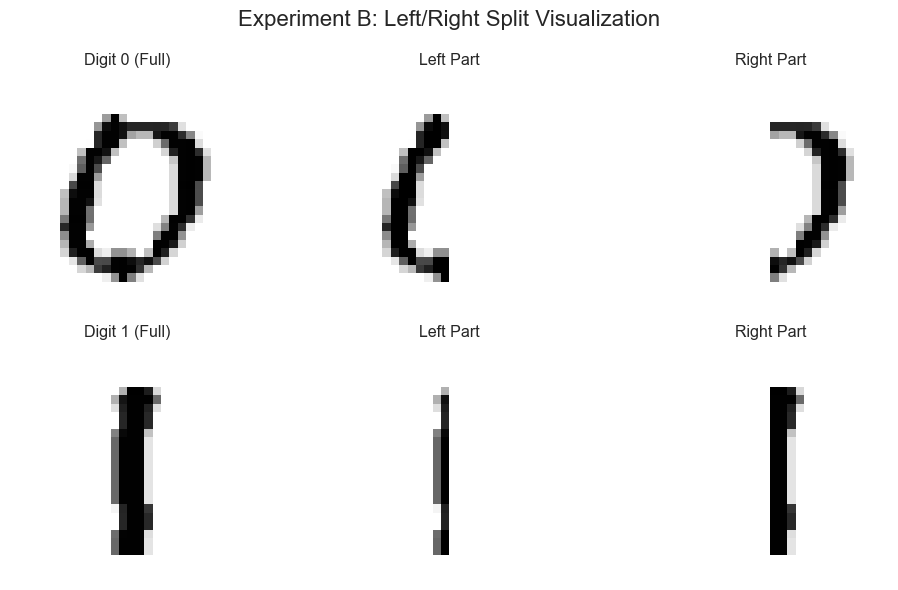


--- Running Data Description: Random Sample 0-9 ---


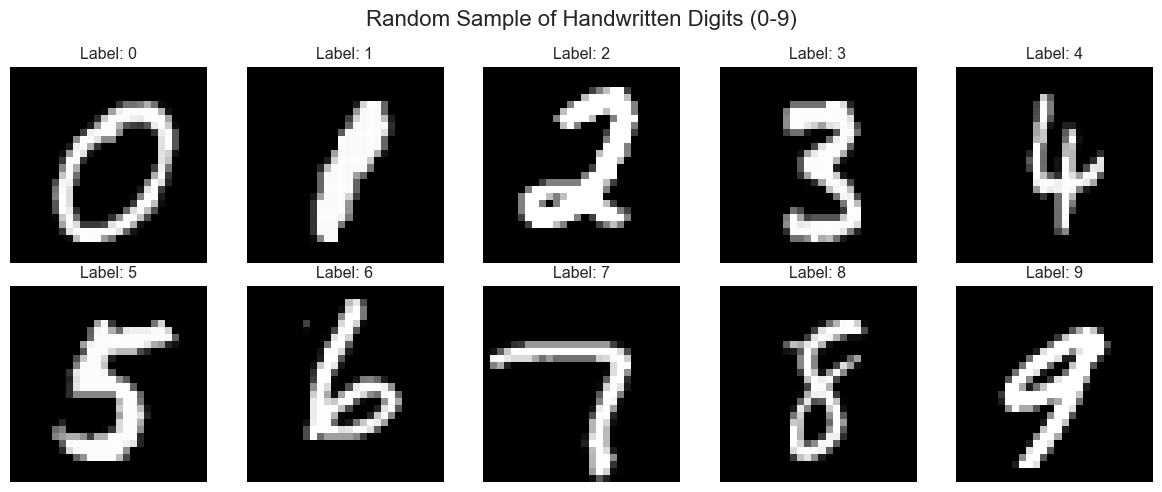

In [8]:
def run_heat_plot_analysis(X, y):
    print("\n--- Running Visual Structure Analysis (Heat Plot) ---")

    # 1. 实验 A: "平均脸" 对比 (The Average Digit)
    digits_to_show = [0, 1, 2, 8]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for i, digit in enumerate(digits_to_show):
        X_digit = X[y == digit]
        if len(X_digit) > 0:
            mean_img = X_digit.mean(axis=0).reshape(28, 28)
            axes[i].imshow(mean_img, cmap='jet')
            axes[i].set_title(f"Average Digit '{digit}'")
        axes[i].axis('off')
    plt.suptitle("Experiment A: Average Pixel Intensity (Heatmap)", fontsize=16)
    plt.show()

    # 2. 实验 B: 左右切分特写 (Left vs Right Split)
    target_digits = [0, 1]
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))

    for row_idx, digit in enumerate(target_digits):
        indices = np.where(y == digit)[0]
        if len(indices) >= 2:
            # 随机选 1 个样本演示
            idx = indices[0]
            img = X[idx].reshape(28, 28)

            # 左半边 (前14列)
            left_half = img[:, :14]
            # 右半边 (后14列)
            right_half = img[:, 14:]
            empty = np.zeros((28, 14))

            # 画完整图
            axes[row_idx, 0].imshow(img, cmap='gray_r')
            axes[row_idx, 0].set_title(f"Digit {digit} (Full)")
            axes[row_idx, 0].axis('off')

            # 画左半边
            axes[row_idx, 1].imshow(np.hstack((left_half, empty)), cmap='gray_r')
            axes[row_idx, 1].set_title("Left Part")
            axes[row_idx, 1].axis('off')

            # 画右半边
            axes[row_idx, 2].imshow(np.hstack((empty, right_half)), cmap='gray_r')
            axes[row_idx, 2].set_title("Right Part")
            axes[row_idx, 2].axis('off')

    plt.suptitle("Experiment B: Left/Right Split Visualization", fontsize=16)
    plt.tight_layout()
    plt.show()


def show_random_digits_0_to_9(X, y):
    """
    Data Description: 随机抽取0-9每个数字的一张图片进行展示
    """
    print("\n--- Running Data Description: Random Sample 0-9 ---")

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()

    for digit in range(10):
        # 获取当前数字的所有索引
        indices = np.where(y == digit)[0]
        if len(indices) > 0:
            # 随机选择一个索引
            random_idx = np.random.choice(indices)
            img = X[random_idx].reshape(28, 28)

            # 绘图
            axes[digit].imshow(img, cmap='gray') # 使用灰度图展示原始数据
            axes[digit].set_title(f"Label: {digit}")
            axes[digit].axis('off')

    plt.suptitle("Random Sample of Handwritten Digits (0-9)", fontsize=16)
    plt.tight_layout()
    plt.show()



# --- 运行此部分 ---
run_heat_plot_analysis(X_global, y_global)
# --- 立即运行查看效果 ---
show_random_digits_0_to_9(X_global, y_global)

### PCA Explore


--- Running Extended PCA Results Analysis ---


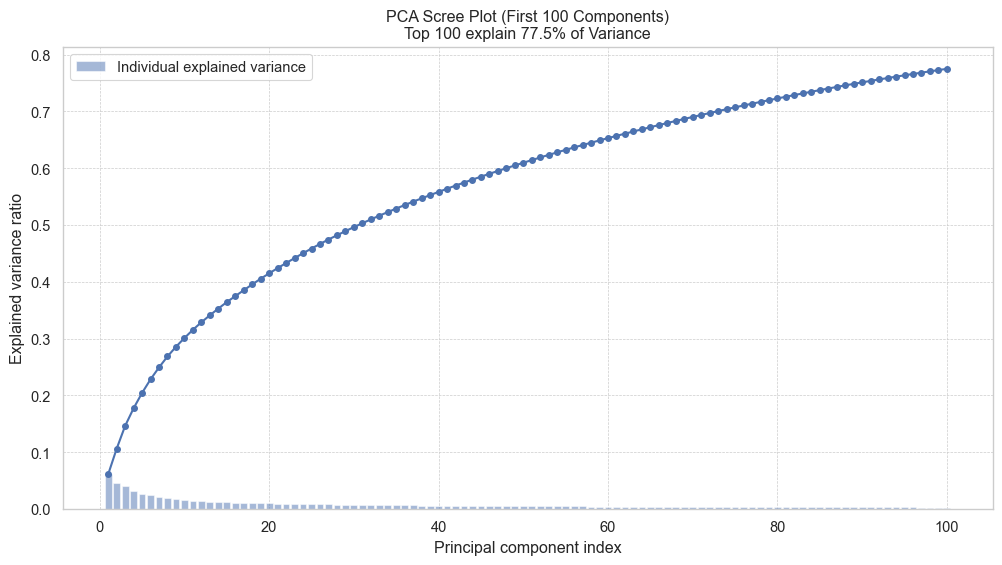

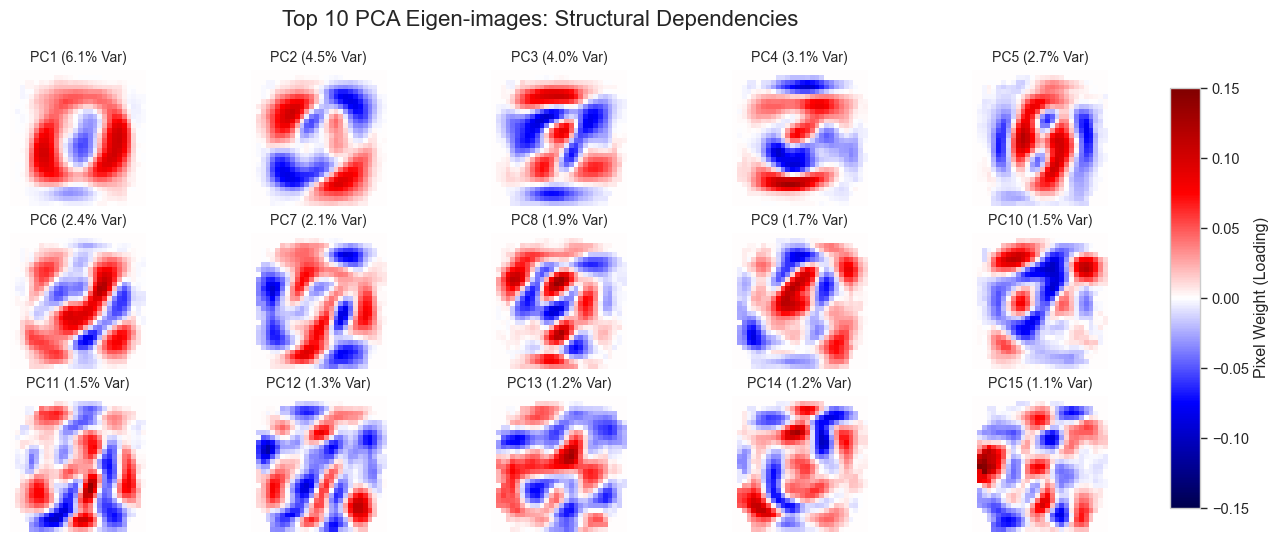

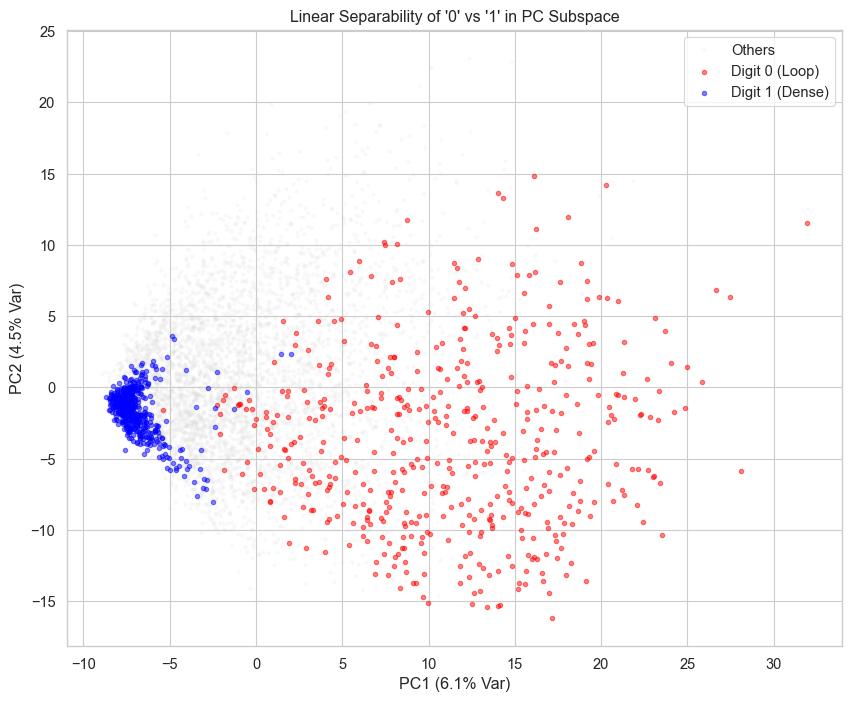

In [9]:
def visualize_extended_pca_insights(X, y):
    print("\n--- Running Extended PCA Results Analysis ---")

    # --- 预处理 (保持和你之前一致的逻辑) ---
    # 1. 移除方差为0的像素
    selector = VarianceThreshold(threshold=0)
    X_filtered = selector.fit_transform(X)

    # 2. 标准化 (Z-score)
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_filtered)

    # --- 任务 A: Scree Plot (碎石图) ---
    # 训练一个较大的PCA来观察Variance分布 (思维导图提到前50个成分)
    n_components_scree = 100
    pca_scree = PCA(n_components=n_components_scree, random_state=42)
    pca_scree.fit(X_std)

    explained_var = pca_scree.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    plt.figure(figsize=(12, 6))

    #Plotting single explained variance of components for each as bar plot
    plt.bar(range(1, n_components_scree + 1), explained_var, alpha=0.5, align='center',
            label='Individual explained variance')

    #Plotting dotted scree plot
    plt.plot(range(1, n_components_scree + 1), cumulative_var, 'b-o', markersize=4, linewidth=1.5)

    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal component index')
    plt.title(f'PCA Scree Plot (First {n_components_scree} Components)\nTop 100 explain {cumulative_var[-1]:.1%} of Variance')
    plt.legend(loc='best')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

    # --- 任务 B: Eigen-images PC1 到 PC10 ---
    # 思维导图核心：从PC1到PC10，观察结构变化 (Topological -> Noise/Detail)

    # 还原特征图需要用到 selector.inverse_transform
    components_full = selector.inverse_transform(pca_scree.components_)

    # 设置绘图：2行5列展示前10个
    fig, axes = plt.subplots(3, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(15):
        # 重塑为28x28
        img = components_full[i].reshape(28, 28)

        # 使用 seismic 或 bwr 颜色映射来显示正负权重 (红色正相关，蓝色负相关)
        # 限制 vmin vmax 以增强对比度
        im = axes[i].imshow(img, cmap='seismic', vmin=-0.15, vmax=0.15)

        var_ratio = explained_var[i]
        axes[i].set_title(f"PC{i+1} ({var_ratio:.1%} Var)", fontsize=10)
        axes[i].axis('off')

    # 添加一个共用的 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Pixel Weight (Loading)')

    plt.suptitle("Top 10 PCA Eigen-images: Structural Dependencies", fontsize=16)
    # plt.tight_layout(rect=[0, 0, 0.9, 1]) # 调整布局给colorbar留空间
    plt.show()

    # --- 任务 C: Digit 0 vs 1 在低维空间的分布 (验证 'Linear Separation') ---
    # 仅使用前两个主成分进行投影
    X_pca_2d = pca_scree.transform(X_std)[:, :2]

    plt.figure(figsize=(10, 8))

    # 定义我们要对比的数字：0 (Open Loop) vs 1 (Center Dense)
    subset_0 = X_pca_2d[y == 0]
    subset_1 = X_pca_2d[y == 1]
    # 为了背景对比，也可以画出其他数字（灰色）
    subset_others = X_pca_2d[(y != 0) & (y != 1)]

    plt.scatter(subset_others[:, 0], subset_others[:, 1], c='lightgray', alpha=0.1, s=5, label='Others')
    plt.scatter(subset_0[:, 0], subset_0[:, 1], c='red', alpha=0.5, s=10, label='Digit 0 (Loop)')
    plt.scatter(subset_1[:, 0], subset_1[:, 1], c='blue', alpha=0.5, s=10, label='Digit 1 (Dense)')

    plt.xlabel(f'PC1 ({explained_var[0]:.1%} Var)')
    plt.ylabel(f'PC2 ({explained_var[1]:.1%} Var)')
    plt.title("Linear Separability of '0' vs '1' in PC Subspace")
    plt.legend()
    plt.show()

# --- 运行新的 PCA 分析函数 ---
visualize_extended_pca_insights(X_global, y_global)

### 5. CCA Explore

In [10]:
def run_cca_experiment(X, y, pca_components=None):
    """
    通用 CCA 分析函数。
    参数:
      pca_components: None (对应 Raw Pixel) 或 int (对应 PCA-Denoised)
    """
    mode_name = f"PCA-{pca_components}" if pca_components else "Raw Pixels"
    print(f"\n>>> Running CCA Analysis Mode: [{mode_name}]")

    n = X.shape[0]
    X_img = X.reshape(n, 28, 28)

    # 1. 构造切分掩码
    rows, cols = np.indices((28, 28))
    mask_main_upper = (rows <= cols)        # Main Diag (\)
    mask_anti_upper = (rows + cols <= 27)   # Anti Diag (/)

    # 2. 定义四种切分
    splits = {
        'L/R (Vertical)': (
            X_img[:, :, :14].reshape(n, -1),
            X_img[:, :, 14:].reshape(n, -1)
        ),
        'T/B (Horizontal)': (
            X_img[:, :14, :].reshape(n, -1),
            X_img[:, 14:, :].reshape(n, -1)
        ),
        'Main Diag (\\)': (
            X_img[:, mask_main_upper],
            X_img[:, ~mask_main_upper]
        ),
        'Anti Diag (/)': (
            X_img[:, mask_anti_upper],
            X_img[:, ~mask_anti_upper]
        )
    }

    results = {'Digit': [], 'Split Type': [], 'Correlation': [], 'Unexplained Variance': []}

    for name, (view1_raw, view2_raw) in splits.items():
        print(f"  Processing split: {name}...")

        # Step A: 基础清理
        sel1 = VarianceThreshold(0)
        sel2 = VarianceThreshold(0)
        try:
            v1 = sel1.fit_transform(view1_raw)
            v2 = sel2.fit_transform(view2_raw)
        except ValueError:
            print(f"Skipping {name}: Constant data.")
            continue

        # Step B: 标准化 (Standardize)
        v1 = StandardScaler().fit_transform(v1)
        v2 = StandardScaler().fit_transform(v2)

        # Step C: 可选 PCA 降维
        if pca_components is not None:
            n_pca = min(pca_components, v1.shape[1], v2.shape[1])
            pca1 = PCA(n_components=n_pca, random_state=42)
            pca2 = PCA(n_components=n_pca, random_state=42)
            v1 = pca1.fit_transform(v1)
            v2 = pca2.fit_transform(v2)

        # Step D: CCA Global Fit
        cca = CCA(n_components=1)
        try:
            U, V = cca.fit_transform(v1, v2)
        except Exception as e:
            print(f"CCA Failed: {e}")
            continue

        # Step E: Subgroup Analysis
        for d in range(10):
            idx = (y == d)
            if np.sum(idx) > 1:
                u_sub = U[idx, 0]
                v_sub = V[idx, 0]

                if np.std(u_sub) == 0 or np.std(v_sub) == 0:
                    corr = 0.0
                else:
                    corr = np.corrcoef(u_sub, v_sub)[0, 1]

                results['Digit'].append(d)
                results['Split Type'].append(name)
                results['Correlation'].append(corr)
                results['Unexplained Variance'].append(1 - corr ** 2)

    return pd.DataFrame(results)

def plot_cca_results(res_df, title_suffix=""):
    fig, axes = plt.subplots(2, 1, figsize=(16, 16))

    # Plot 1: Correlation
    ax1 = sns.barplot(data=res_df, x='Digit', y='Correlation', hue='Split Type', ax=axes[0], palette="viridis")
    axes[0].set_title(f"Structural Redundancy: {title_suffix}")
    axes[0].set_ylim(0, 1.25)
    axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    for c in ax1.containers:
        ax1.bar_label(c, fmt='%.3f', padding=3, fontsize=9, rotation=90)

    # Plot 2: MSE
    ax2 = sns.barplot(data=res_df, x='Digit', y='Unexplained Variance', hue='Split Type', ax=axes[1], palette="rocket")
    axes[1].set_title(f"Structural Uncertainty (1-r^2): {title_suffix}")
    axes[1].set_ylabel("Unexplained Variance")
    axes[1].set_ylim(0, 1.25)
    axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    for c in ax2.containers:
        ax2.bar_label(c, fmt='%.3f', padding=3, fontsize=9, rotation=90)

    plt.tight_layout()
    plt.show()

### 6. CCA Execution without PCA



>>> Running CCA Analysis Mode: [Raw Pixels]
  Processing split: L/R (Vertical)...
  Processing split: T/B (Horizontal)...
  Processing split: Main Diag (\)...
  Processing split: Anti Diag (/)...


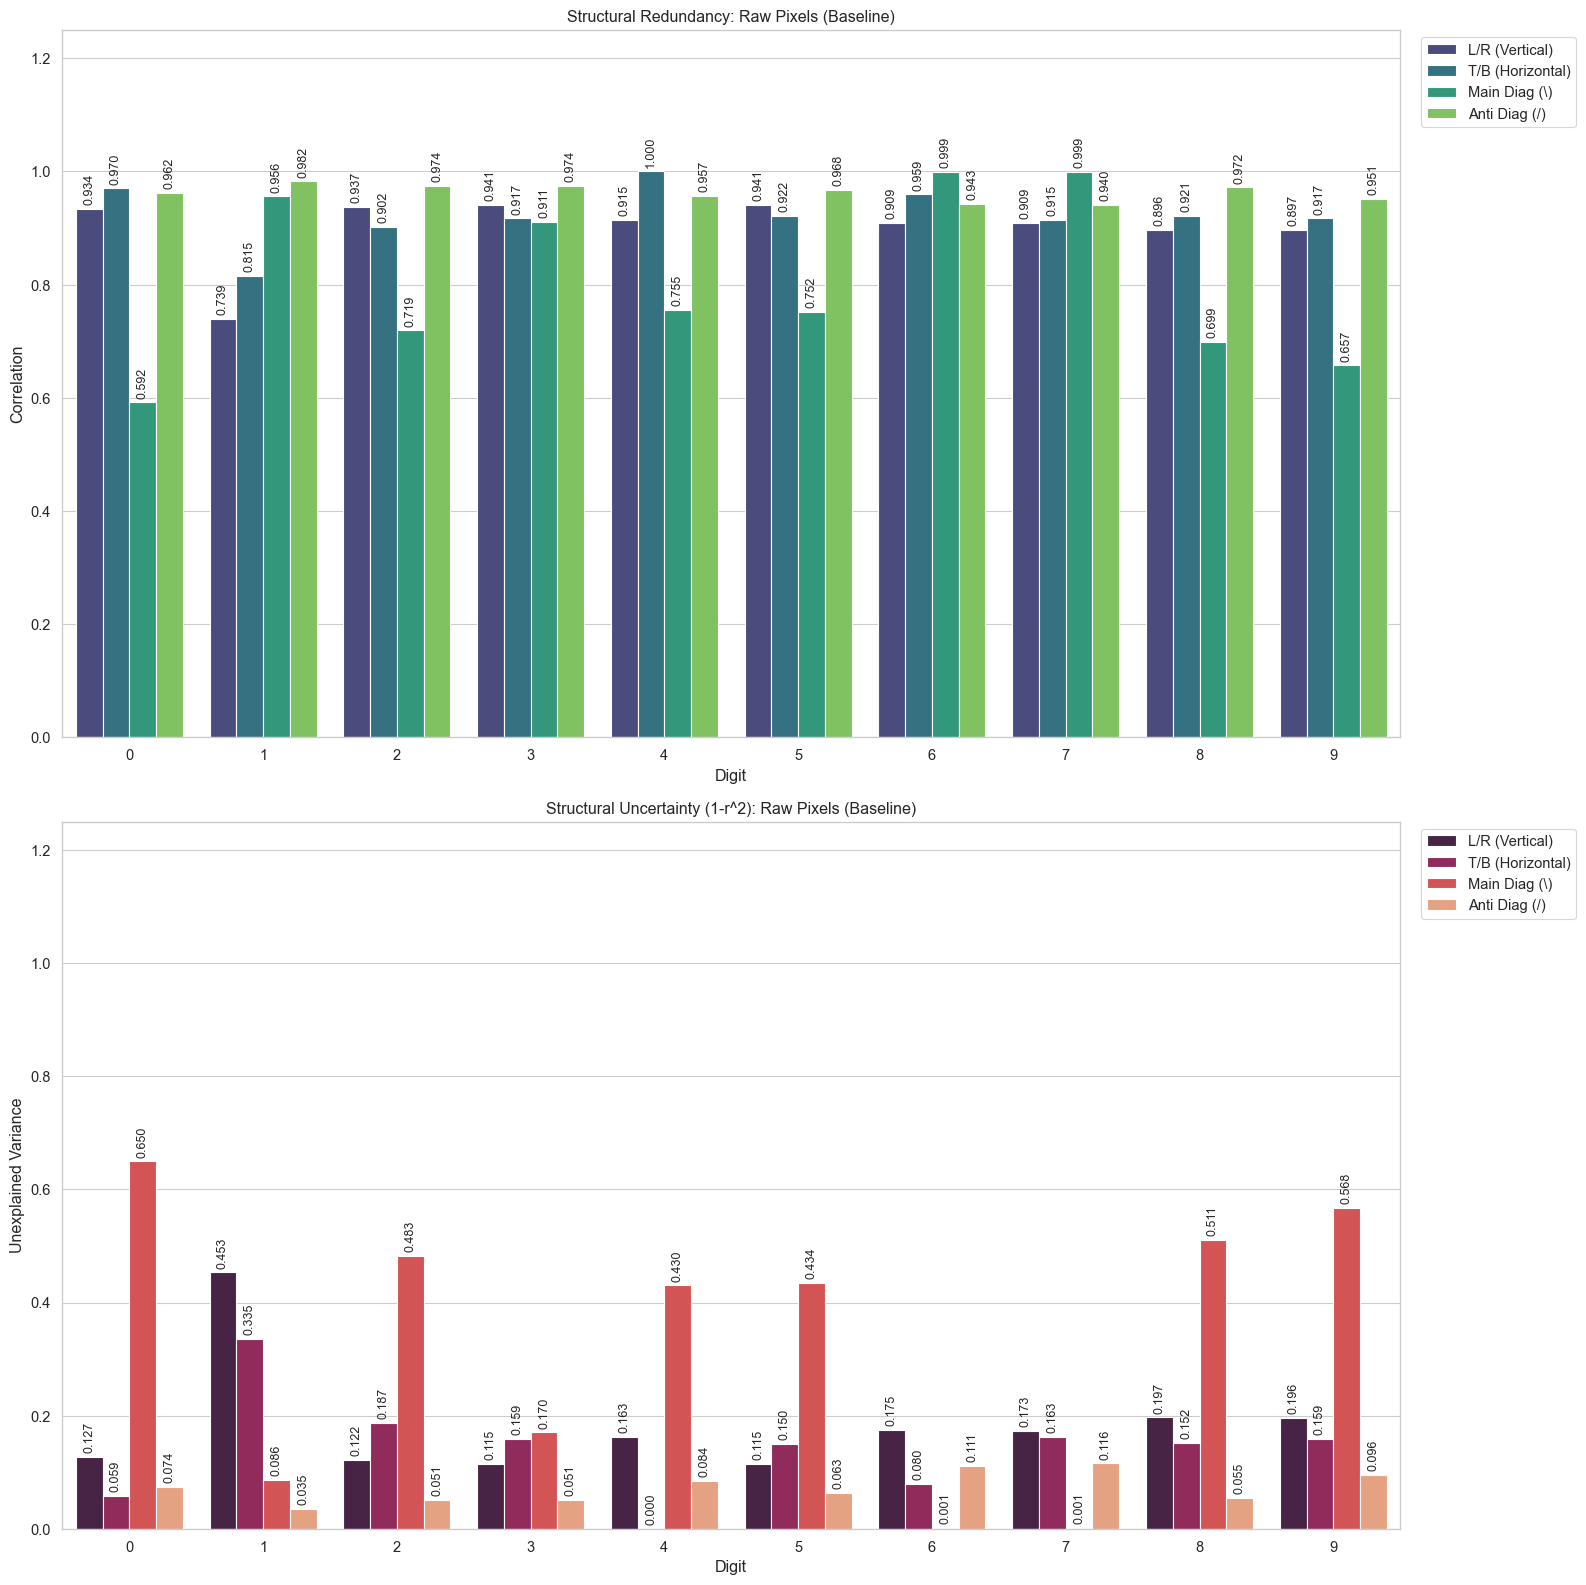

In [6]:
# 运行不带 PCA 的版本
df_raw = run_cca_experiment(X_global, y_global, pca_components=None)

# 画图
plot_cca_results(df_raw, title_suffix="Raw Pixels (Baseline)")

### 7. CCA Execution: With PCA


>>> Running CCA Analysis Mode: [PCA-50]
  Processing split: L/R (Vertical)...
  Processing split: T/B (Horizontal)...
  Processing split: Main Diag (\)...
  Processing split: Anti Diag (/)...


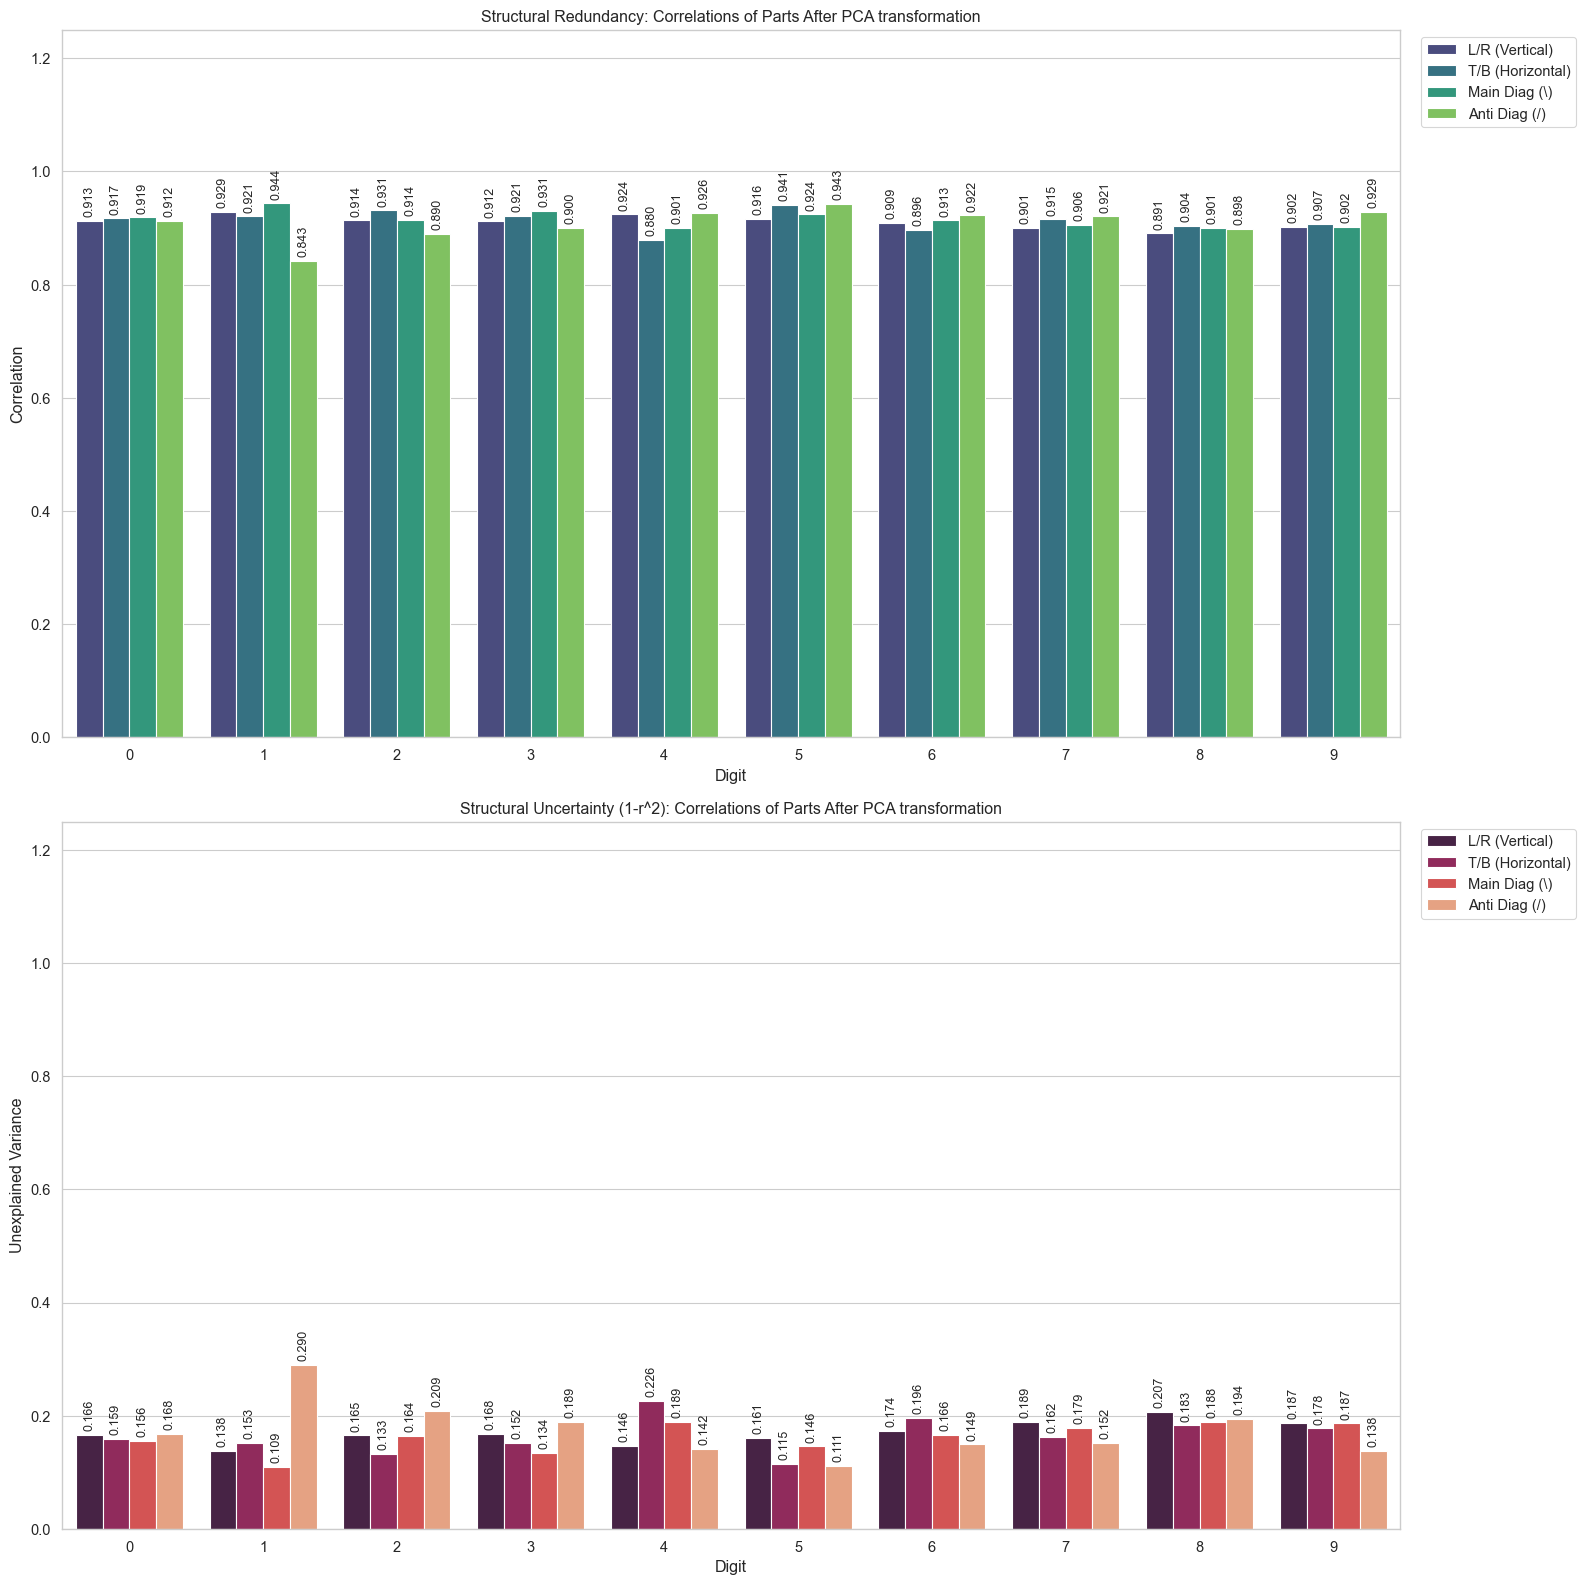

In [11]:
df_pca5 = run_cca_experiment(X_global, y_global, pca_components=50)
plot_cca_results(df_pca5, title_suffi

x="Correlations of Parts After PCA transformation")